In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("food_delivery_orders.csv")

df.head()

,order_date,city,restaurant_category,cuisine,order_value,discount_percent,delivery_time_min,rating,profit_per_order
0,2023-01-01,Karachi,Fine Dining,Continental,2768.0,25.0,36.2,4.5,95.0
1,2023-01-01,Karachi,Fine Dining,Steakhouse,4979.0,44.8,23.3,4.8,-437.0
2,2023-01-01,Karachi,Cloud Kitchen,Indian,4008.0,11.9,39.6,4.2,618.0
3,2023-01-01,Islamabad,Fine Dining,Steakhouse,3260.0,8.3,35.8,4.5,423.0
4,2023-01-01,Karachi,Fast Food,Pizza,435.0,13.5,29.4,4.8,53.0


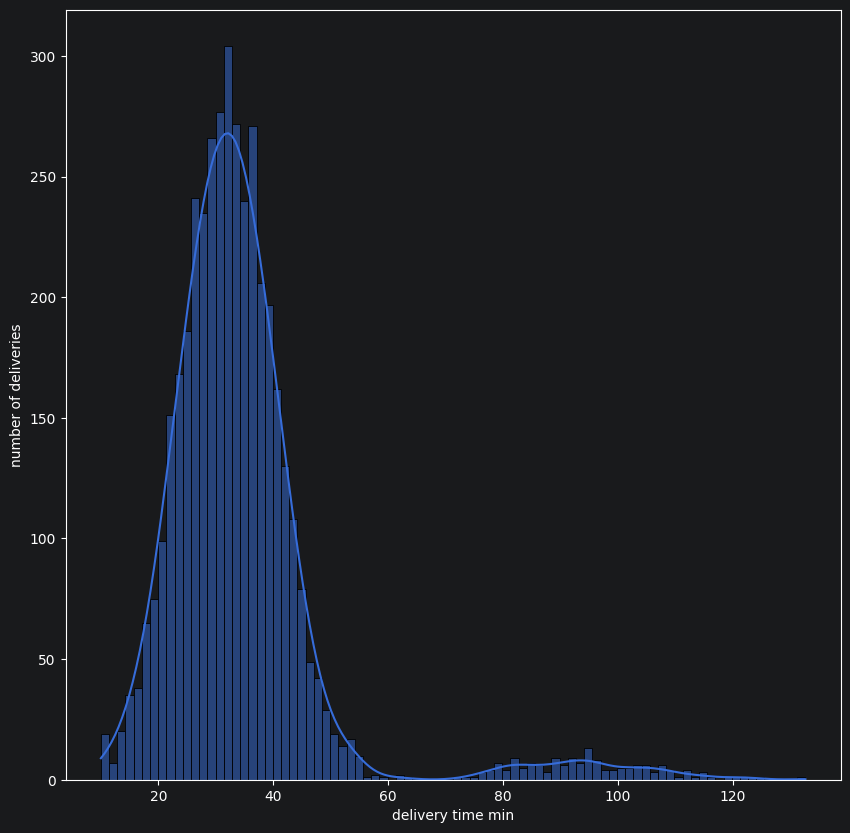

skewness: 2.8770611473024483
mean_delivery: 34.541809523809526
median_delivery: 32.5


In [6]:
#only one variable - delivery_time_min so univariate
#kde kernel density estimate, makes a curve on the histogram
#shows the concentration of data

plt.figure(figsize=(10,10))
sns.histplot(df['delivery_time_min'], kde=True)
plt.xlabel('delivery time min')
plt.ylabel('number of deliveries')
plt.show()

skewness=df['delivery_time_min'].skew()
print("skewness:",skewness)

mean_delivery=df['delivery_time_min'].mean()
median_delivery=df['delivery_time_min'].median()

print("mean_delivery:",mean_delivery)
print("median_delivery:",median_delivery)

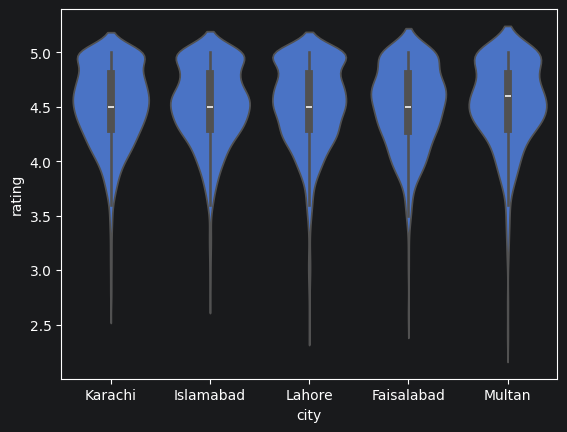

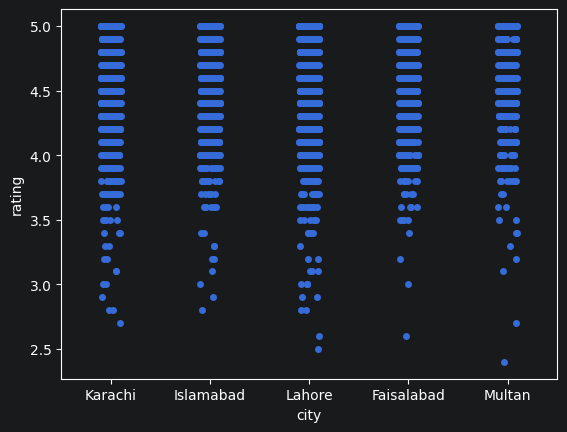

In [8]:
sns.violinplot(data=df, x='city', y='rating')
plt.xlabel('city')
plt.ylabel('rating')
plt.show()

sns.stripplot(data=df, x='city', y='rating', jitter=True)
plt.xlabel('city')
plt.ylabel('rating')
plt.show()

#violin shows shape of distribution and shows patterns that would be hidden in bar chart
#jitter shows all the individual values

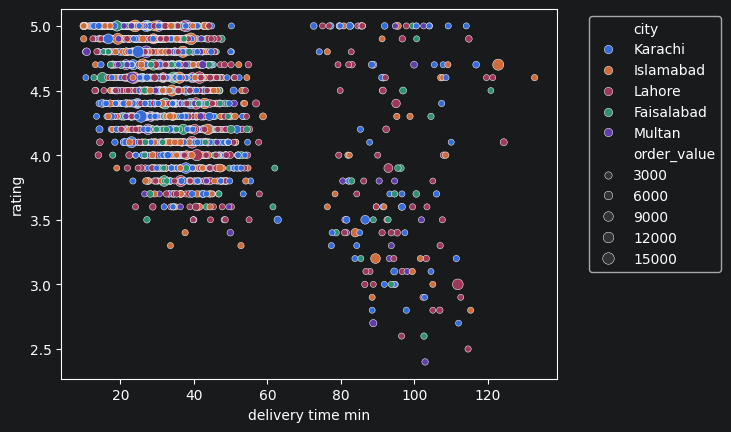

In [11]:
sns.scatterplot(data=df, x='delivery_time_min', y='rating', hue='city', size='order_value')
plt.xlabel('delivery time min')
plt.ylabel('rating')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

                   order_value  discount_percent  delivery_time_min    rating  \
order_value           1.000000         -0.011191           0.002202  0.003122   
discount_percent     -0.011191          1.000000           0.013286 -0.006129   
delivery_time_min     0.002202          0.013286           1.000000 -0.445474   
rating                0.003122         -0.006129          -0.445474  1.000000   
profit_per_order     -0.657144         -0.081982          -0.030879  0.014360   

                   profit_per_order  
order_value               -0.657144  
discount_percent          -0.081982  
delivery_time_min         -0.030879  
rating                     0.014360  
profit_per_order           1.000000  
                   order_value  discount_percent  delivery_time_min    rating  \
order_value           1.000000          0.007783          -0.020271  0.004487   
discount_percent      0.007783          1.000000           0.019502 -0.002619   
delivery_time_min    -0.020271          0.

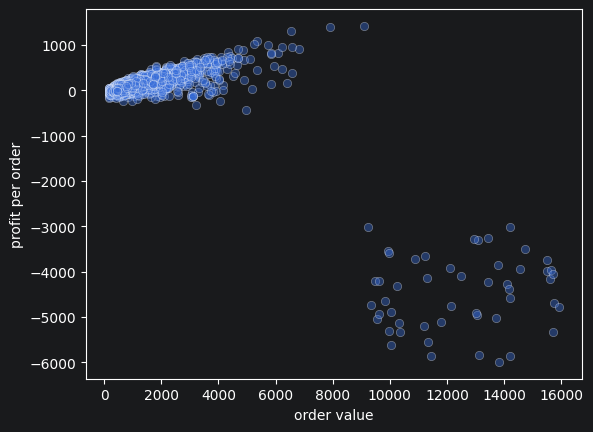

Original Pearson: -0.6571444205999949
Original Spearman: 0.6731141221600551

Without extreme orders:
Pearson: 0.7787368862721235
Spearman: 0.7341259682247819


In [17]:
numeric_cols=['order_value', 'discount_percent','delivery_time_min','rating', 'profit_per_order']

pearson_corr=df[numeric_cols].corr(method="pearson")
print(pearson_corr)

spearman_corr=df[numeric_cols].corr(method="spearman")
print(spearman_corr)

difference = abs(pearson_corr - spearman_corr)
print(difference)

sns.scatterplot(data=df, x='order_value', y='profit_per_order', alpha=0.4)
plt.xlabel('order value')
plt.ylabel('profit per order')
plt.show()

normal_orders = df[df['order_value'] <= 8000]

print("Original Pearson:",
      df['order_value'].corr(df['profit_per_order'], method='pearson'))

print("Original Spearman:",
      df['order_value'].corr(df['profit_per_order'], method='spearman'))

print("\nWithout extreme orders:")

print("Pearson:",
      normal_orders['order_value'].corr(
          normal_orders['profit_per_order'],
          method='pearson'
      ))

print("Spearman:",
      normal_orders['order_value'].corr(
          normal_orders['profit_per_order'],
          method='spearman'
      ))

#the large disagreement is because of a handful of extreme values, btu should not be dropped unless there is incorrect or unusual data in there

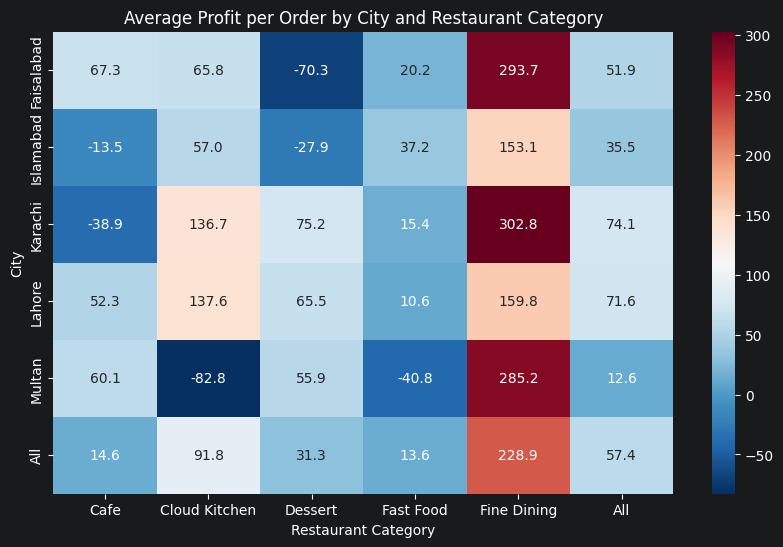

Most profitable combination: ('Karachi', 'Fine Dining')
Average profit per order: 302.8014184397163


In [20]:
pivot = pd.pivot_table(
    df,
    index='city',
    columns='restaurant_category',
    values='profit_per_order',
    aggfunc='mean',
    margins=True
)

pivot

plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="RdBu_r"
)

plt.title("Average Profit per Order by City and Restaurant Category")
plt.xlabel("Restaurant Category")
plt.ylabel("City")

plt.show()

pivot_no_all = pivot.drop(index='All').drop(columns='All')

max_location = pivot_no_all.stack().idxmax()
max_profit = pivot_no_all.stack().max()

print("Most profitable combination:", max_location)
print("Average profit per order:", max_profit)

order_date
2023-01-31    4.536652
2023-02-28    4.504206
2023-03-31    4.535741
2023-04-30    4.544681
2023-05-31    4.504405
2023-06-30    4.512653
2023-07-31    4.534272
2023-08-31    4.504781
2023-09-30    4.505221
2023-10-31    4.503042
2023-11-30    4.526000
2023-12-31    4.484348
2024-01-31    4.451442
2024-02-29    4.455510
2024-03-31    4.518534
2024-04-30    4.496053
2024-05-31    4.522368
2024-06-30    4.519758
Freq: ME, Name: rating, dtype: float64
order_date
2023-01-31         NaN
2023-02-28         NaN
2023-03-31    4.525533
2023-04-30    4.528209
2023-05-31    4.528276
2023-06-30    4.520580
2023-07-31    4.517110
2023-08-31    4.517235
2023-09-30    4.514758
2023-10-31    4.504348
2023-11-30    4.511421
2023-12-31    4.504463
2024-01-31    4.487263
2024-02-29    4.463767
2024-03-31    4.475162
2024-04-30    4.490032
2024-05-31    4.512319
2024-06-30    4.512726
Freq: ME, Name: rating, dtype: float64


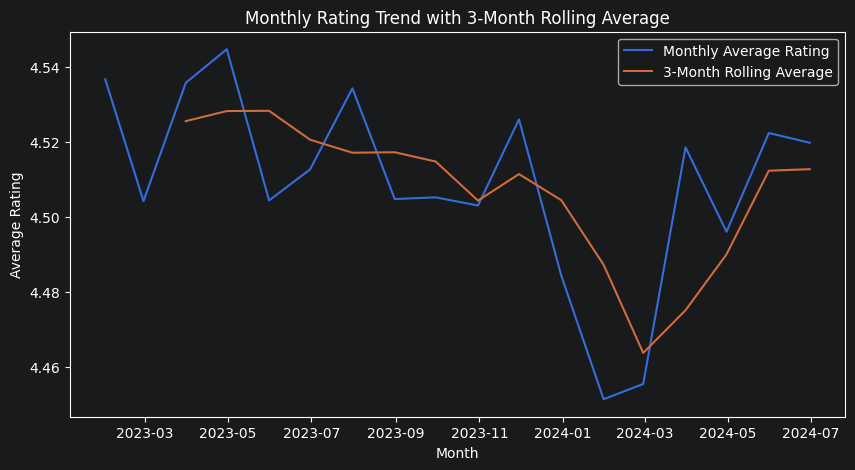

In [29]:
#df['order_date'] = pd.to_datetime(df['order_date'])

#df = df.set_index('order_date')

monthly_rating = df['rating'].resample('ME').mean()

print(monthly_rating)

rolling_rating = monthly_rating.rolling(window=3).mean()

print(rolling_rating)

plt.figure(figsize=(10, 5))

plt.plot(monthly_rating, label='Monthly Average Rating')
plt.plot(rolling_rating, label='3-Month Rolling Average')

plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.title("Monthly Rating Trend with 3-Month Rolling Average")

plt.legend()
plt.show()

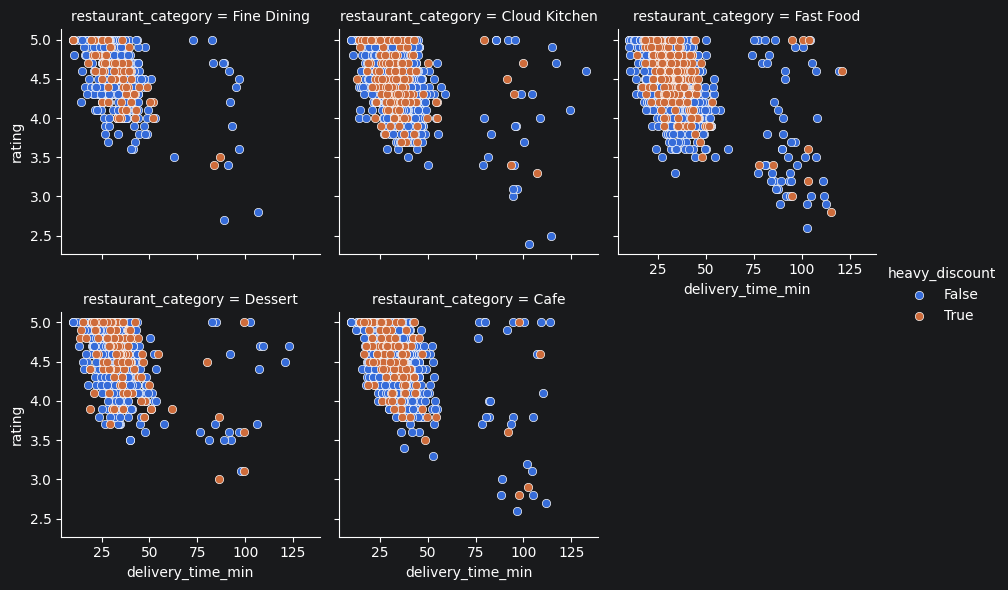

In [32]:
df['heavy_discount'] = df['discount_percent'] > 20

g = sns.FacetGrid(
    df,
    col='restaurant_category',
    hue='heavy_discount',
    col_wrap=3
)

g.map(
    sns.scatterplot,
    'delivery_time_min',
    'rating'
)

g.add_legend()

plt.show()


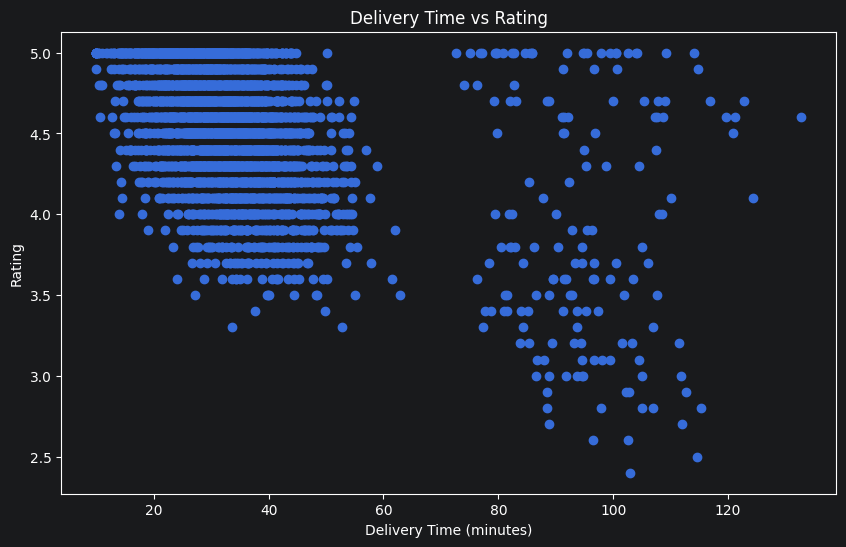

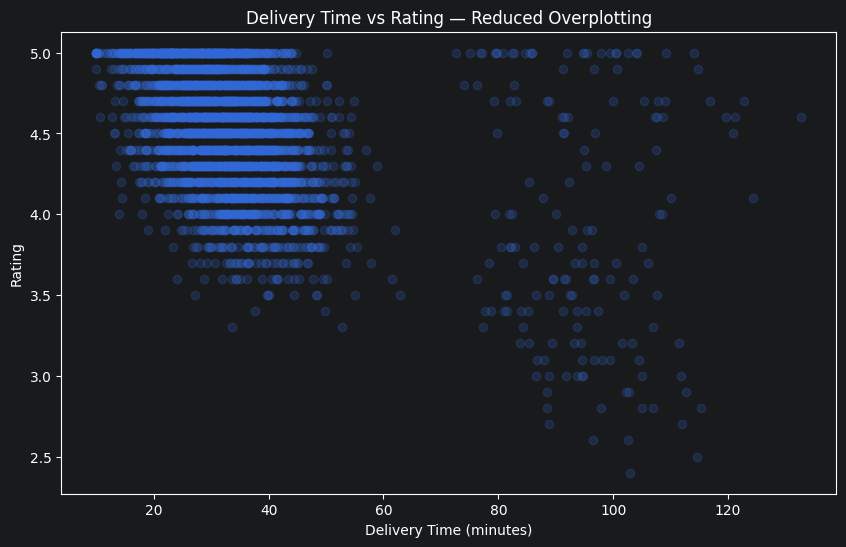

city                     Karachi
restaurant_category    Fast Food
cuisine                  Burgers
order_value                844.0
discount_percent            21.2
delivery_time_min           95.0
rating                       5.0
profit_per_order           -23.0
heavy_discount              True
Name: 2023-03-21 00:00:00, dtype: object
                 city restaurant_category    cuisine  order_value  \
order_date                                                          
2024-02-11    Karachi                Cafe  Breakfast        337.0   
2024-02-11  Islamabad             Dessert      Cakes        339.0   

            discount_percent  delivery_time_min  rating  profit_per_order  \
order_date                                                                  
2024-02-11               9.7               14.5     5.0              35.0   
2024-02-11              38.2               19.0     3.9             -15.0   

            heavy_discount  
order_date                  
2024-02-11        

In [36]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['delivery_time_min'],
    df['rating']
)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Rating")
plt.title("Delivery Time vs Rating")

plt.show()

plt.figure(figsize=(10, 6))

plt.scatter(
    df['delivery_time_min'],
    df['rating'],
    alpha=0.2
)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Rating")
plt.title("Delivery Time vs Rating — Reduced Overplotting")

plt.show()

long_delivery = df[df['delivery_time_min'] > 90]

best_long = long_delivery.loc[
    long_delivery['rating'].idxmax()
]

print(best_long)

fast_delivery = df[df['delivery_time_min'] < 20]

worst_fast = fast_delivery.loc[
    fast_delivery['rating'].idxmin()
]

print(worst_fast)